In [29]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [31]:
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df['HeartDisease'].value_counts()       # to check if output variable has equal distribution

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

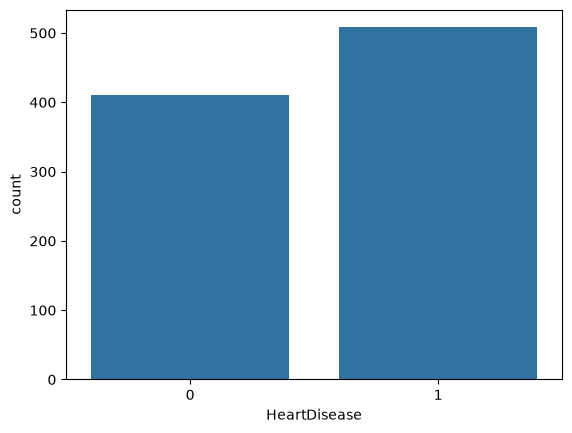

In [43]:
sb.countplot(x = df['HeartDisease'])

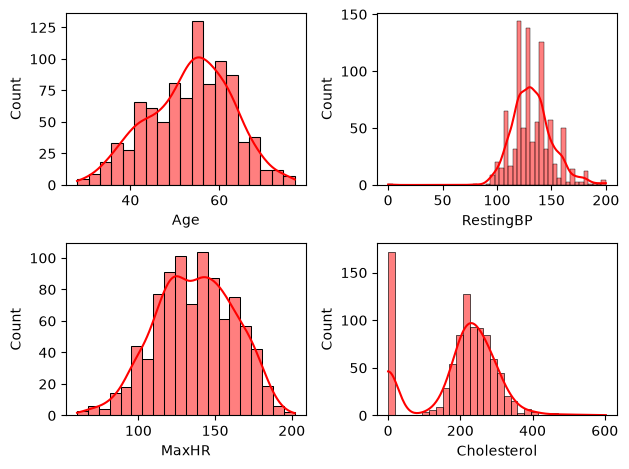

In [38]:
def vis(var, num):
    plt.subplot(2, 2, num)
    sb.histplot(df[var], kde = 1, color='red')

vis('Age', 1)
vis('RestingBP', 2)
vis('MaxHR', 3)
vis('Cholesterol', 4)

plt.tight_layout()

0 cholestrol and 0 restingBP isnt possible for any human being, hence making clear the data needs to be cleaned

In [39]:
#replacing both with their data domain mean/median

chol_median = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
rbp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['Cholesterol'] = df['Cholesterol'].replace(0, chol_median)
df['RestingBP'] = df['RestingBP'].replace(0, rbp_mean)

df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)



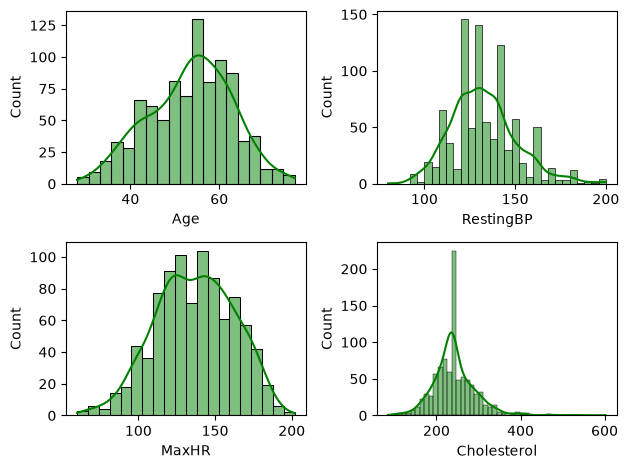

In [41]:
def vis(var, num):
    plt.subplot(2, 2, num)
    sb.histplot(df[var], kde = 1, color='green')

vis('Age', 1)
vis('RestingBP', 2)
vis('MaxHR', 3)
vis('Cholesterol', 4)

plt.tight_layout()

<Axes: xlabel='ChestPainType', ylabel='count'>

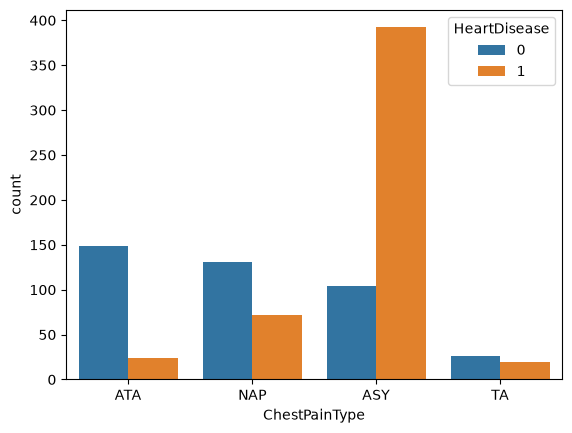

In [45]:
# checking affecting factors against categorical attributes
sb.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])